# I 320D: Data Science for Biomedical Informatics
## Project 15: Microbiome Temporal Dynamics and Disease State
### Joshua Hamilton | 10-Step Framework | Spring 2026 | University of Texas at Austin · School of Information

---

> This notebook walks through all 10 steps to characterize temporal variability in the gut microbiome
> across healthy and IBD subjects using the HMP2 longitudinal dataset.

---

## Quick Reference Table

| Step | Title | Core Concept | Key Challenge |
|------|-------|--------------|---------------|
| 0 | Environment Setup | Reproducibility; HMP2 `.tsv` files | Compositional data is fundamentally different from clinical time series |
| 1 | Data Loading | 132 subjects × 2,290 stool samples; 16S OTU counts | Irregular sampling intervals; subjects missing timepoints |
| 2 | EDA | Compositional distributions; per-subject diversity trajectories | Zero-inflation and compositional constraints invalidate standard EDA |
| 3 | CLR Transformation | Convert compositions to real-valued log-ratios | Zeros break CLR — pseudo-count strategy required |
| 4 | Feature Engineering | Temporal stability index; trailing trajectory features | Rolling windows on irregular time grids; Bray-Curtis dissimilarity |
| 5 | Train/Test Split | Subject-level split; stratify by disease group | Three-class imbalance: healthy, Crohn's, UC |
| 6 | Baseline Model | Logistic regression on mean CLR-transformed trajectory | Features are high-dimensional (~500 OTUs); sparsity regularization needed |
| 7 | Temporal Model | LSTM on 2-week trailing microbiome trajectory | Very sparse temporal coverage — not a dense time series |
| 8 | Evaluation | Flare prediction lead-time; per-subject AUROC | Flare definitions are clinical, not microbiome-derived |
| 9 | Interpretation | SHAP on LR; OTU-level importance; PCoA trajectory visualization | Which taxa drive dysbiosis vs. which drive flare prediction? |

---

## Step 0 — Environment Setup & Data Download

| | **Project 15: Microbiome** |
|---|---|
| **Dataset** | HMP2 (iHMP) via HMPDACC (hmpdacc.org) — freely available |
| **File Format** | `.tsv` OTU count tables; one row per sample, one column per taxon |
| **Credentialing** | None required — register at hmpdacc.org for download access |
| **Key Libraries** | `pandas`, `numpy`, `sklearn`, `torch`, `shap`, `skbio` (for Bray-Curtis), `matplotlib`, `seaborn` |
| **Reproducibility Goal** | Fixed seeds; pinned library versions; document which subject IDs are train vs. test |
| **Core Pitfall** | Treating OTU count tables as ordinary numeric data — they are compositional |
| **New Concept** | Compositional data: all values in a sample sum to a constant (read depth or 1.0 after normalization) |

**What changes pedagogically:** The microbiome is a *composition* — a set of relative abundances that sum to 1. This fundamentally changes every downstream analysis step. Students must build new intuition from the ground up.

In [1]:
# ── Step 0: Environment Setup ──────────────────────────────────────────────
import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.model_selection import LeaveOneGroupOut

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import shap
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Environment ready.")
print(f"Torch version: {torch.__version__}")
print(f"Pandas version: {pd.__version__}")

# ── Data Download Instructions ─────────────────────────────────────────────
# 1. Visit https://hmpdacc.org/hmp/HMP2/
# 2. Download the 16S rRNA amplicon (OTU) count table
# 3. Download the subject metadata (disease status, visit dates, flare annotations)
# 4. Place files in ./data/hmp2/

DATA_DIR = "./data/hmp2/"
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR}")

Environment ready.
Torch version: 2.11.0+cpu
Pandas version: 3.0.2
Data directory: ./data/hmp2/


C:\Users\joshu\data_science_projects\I320D-Project-3\jupyter_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## Step 1 — Data Loading & First Look

| | **Project 15: Microbiome** |
|---|---|
    | **Data Structure** | SubjectID → week_num → bacterial relative abundance vector → DiseaseStatus + FlareLabel |
| **Label Definition** | FlareLabel = 1 when fecal calprotectin > 250 μg/g, indicating active intestinal inflammation; 0 otherwise. |
| **Class Imbalance** | ~35% healthy subjects; ~35% Crohn's disease; ~30% ulcerative colitis; flares are a minority of samples within IBD subjects |
| **Temporal Resolution** | ~1 sample per 2 weeks (highly irregular) |
| **Longitudinal Structure** | Months of outpatient stool sampling |
| **Key Clinical Definition** | IBD flare: clinician-adjudicated symptom exacerbation; does not have a single biomarker threshold |
| **Core Pitfall** | Treating samples as independent; ignoring that samples within a subject are correlated |

**What changes pedagogically:** Unlike many clinical prediction tasks, flare labels here are *clinical judgments*. This introduces **label noise** as a first-class problem. A microbiome signal may precede a flare that was labeled at the clinic visit — creating uncertain label timing.

In [2]:
# ── Step 1: Data Loading ───────────────────────────────────────────────────

import os
import pandas as pd
import numpy as np

DATA_DIR = "./data/hmp2/"

df = pd.read_csv(DATA_DIR + "hmp2_ibd_metagenomics_atlas_20260219_121629.csv")

otu_df = df.rename(columns={
    "External ID": "SampleID",
    "Participant ID": "SubjectID",
    "diagnosis": "Disease",
    "week_num": "VisitNum"
})

otu_df["FlareLabel"] = (otu_df["fecalcal"] > 250).astype(int)

metadata_cols = [
    "SampleID",
    "SubjectID",
    "VisitNum",
    "Disease",
    "fecalcal",
    "dysbiosis_score",
    "antibiotics",
    "FlareLabel"
]

otu_cols = [col for col in otu_df.columns if col not in metadata_cols]

print(f"Dataset shape: {otu_df.shape}")
print(f"Subjects: {otu_df['SubjectID'].nunique()}")

print("\nDisease distribution:")
print(otu_df.groupby("Disease")["SubjectID"].nunique())

print(f"\nFlare prevalence: {otu_df['FlareLabel'].mean():.1%} of all samples")
print(f"\nNumber of bacteria columns: {len(otu_cols)}")

otu_df.head()

Dataset shape: (3387, 572)
Subjects: 116

Disease distribution:
Disease
Crohns Disease        56
Healthy               27
Ulcerative Colitis    33
Name: SubjectID, dtype: int64

Flare prevalence: 6.6% of all samples

Number of bacteria columns: 566


,SampleID,SubjectID,VisitNum,Disease,fecalcal,Bacteroides vulgatus,Bacteroides uniformis,Bacteroides thetaiotaomicron,Faecalibacterium prausnitzii,Roseburia faecis,...,Prevotella pallens,Chlamydia ibidis,Enterococcus mundtii,Anaerostipes sp 992a,Actinobaculum sp oral taxon 183,Lachnoclostridium sp An298,Haemophilus haemolyticus,Enterococcus dispar,Atopobium minutum,FlareLabel
0,CSM5FZ3N,C3001,0.0,Crohns Disease,193.89000,42.34520,31.29744,6.81155,5.29200,5.01599,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,CSM5FZ4C,C3001,8.0,Crohns Disease,61.34000,12.29822,28.74672,26.46909,2.74544,2.73659,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,CSM5MCVV,C3001,16.0,Crohns Disease,115.27000,12.38214,15.91063,3.77383,0.25195,0.24233,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,CSM67UA2,C3001,28.0,Crohns Disease,23.20350,36.69818,28.04901,16.81345,1.25428,1.94912,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,CSM79HGP,C3001,38.0,Crohns Disease,37.17836,33.26674,36.24943,7.88757,1.20698,1.48374,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


---

## Step 2 — Exploratory Data Analysis (EDA)

| | **Project 15: Microbiome** |
|---|---|
| **Class Balance Plot** | Subject-level (3-class) and sample-level flare prevalence |
| **Signal Distributions** | Bacterial relative abundance distributions; alpha diversity per subject |
| **Missing Data Focus** | Not missing in the traditional sense — but zero-inflated: many bacterial taxa are absent in a given sample |
| **Temporal Trend Analysis** | Per-subject alpha diversity trajectory; beta diversity (Bray-Curtis) between consecutive samples |
| **Inter-subject Heterogeneity** | Microbiome composition varies more between people than within a single person over time |
| **New EDA Task** | PCoA plot of all samples colored by disease status; identify whether groups cluster |
| **Core Pitfall** | Using Pearson correlation or PCA directly on relative abundances — standard Euclidean methods can be misleading for compositional data |

**What changes pedagogically:** The main challenge in microbiome EDA is the geometry of the data space itself. Relative abundances do not lie in unconstrained Euclidean space — they exist in a simplex where values are dependent and sum to a constant. This makes standard statistical methods inappropriate and motivates the use of transformations such as CLR in the next step.

**Challenge questions:**
- 72. Microbiome relative abundances are compositional — they sum to 1 and are therefore not independent. What goes wrong if you analyze them with standard statistical methods that assume independence? Standard statistical methods assume variables are independent and lie in Euclidean space. Microbiome relative abundances violate this because they are constrained to sum to a constant, meaning an increase in one taxon must correspond to decreases in others. This induces spurious correlations and makes distance metrics like Euclidean distance misleading.

Number of bacteria columns: 566
Example bacteria columns:
['Bacteroides vulgatus', 'Bacteroides uniformis', 'Bacteroides thetaiotaomicron', 'Faecalibacterium prausnitzii', 'Roseburia faecis', 'Bacteroides caccae', 'Clostridium clostridioforme', 'Bacteroides fragilis', 'Fusicatenibacter saccharivorans', 'Flavonifractor plautii']

Relative abundance row-sum check:
count    3387.000000
mean      100.000000
std         0.000021
min        99.999930
25%        99.999990
50%       100.000000
75%       100.000010
max       100.000080
dtype: float64

Mean zero fraction across bacteria: 91.0%
Bacteria that are >90% zero: 440 / 566


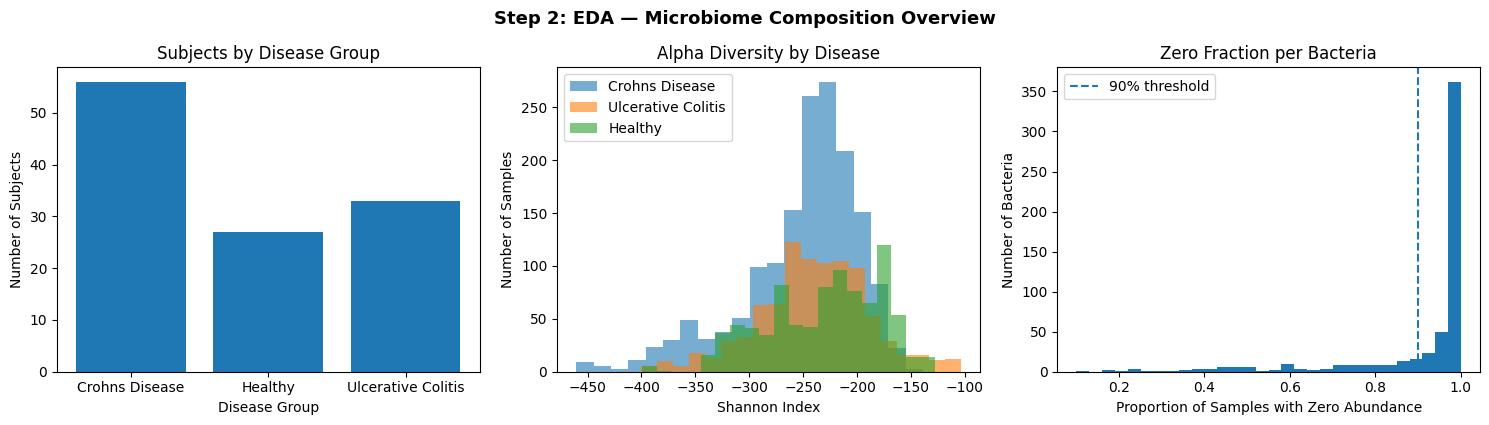


Note: The bacteria columns are already relative abundances, so this step does not re-normalize them.
Step 3 applies CLR transformation for compositional analysis.


In [3]:
# ── Step 2: Exploratory Data Analysis ──────────────────────────────────────

# Identify bacteria columns
metadata_cols = [
    "SampleID",
    "SubjectID",
    "VisitNum",
    "Disease",
    "fecalcal",
    "dysbiosis_score",
    "antibiotics",
    "FlareLabel"
]

otu_cols = [col for col in otu_df.columns if col not in metadata_cols]

print(f"Number of bacteria columns: {len(otu_cols)}")
print("Example bacteria columns:")
print(otu_cols[:10])

# ── 2a. Check that relative abundances approximately sum to 1 ───────────────
row_sums = otu_df[otu_cols].sum(axis=1)

print("\nRelative abundance row-sum check:")
print(row_sums.describe())

# ── 2b. Alpha diversity: Shannon index ─────────────────────────────────────
def shannon(row):
    p = row[row > 0]
    return -np.sum(p * np.log(p))

otu_df["Shannon"] = otu_df[otu_cols].apply(lambda r: shannon(r.values), axis=1)

# ── 2c. Zero-inflation ─────────────────────────────────────────────────────
zero_frac = (otu_df[otu_cols] == 0).mean()

print(f"\nMean zero fraction across bacteria: {zero_frac.mean():.1%}")
print(f"Bacteria that are >90% zero: {(zero_frac > 0.9).sum()} / {len(otu_cols)}")

# ── 2d. Plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class balance
disease_counts = otu_df.groupby("Disease")["SubjectID"].nunique()
axes[0].bar(disease_counts.index, disease_counts.values)
axes[0].set_title("Subjects by Disease Group")
axes[0].set_ylabel("Number of Subjects")
axes[0].set_xlabel("Disease Group")

# Shannon diversity by disease
for disease in otu_df["Disease"].dropna().unique():
    subset = otu_df[otu_df["Disease"] == disease]["Shannon"]
    axes[1].hist(subset, alpha=0.6, label=disease, bins=20)

axes[1].set_title("Alpha Diversity by Disease")
axes[1].set_xlabel("Shannon Index")
axes[1].set_ylabel("Number of Samples")
axes[1].legend()

# Zero-inflation distribution
axes[2].hist(zero_frac.values, bins=30)
axes[2].set_title("Zero Fraction per Bacteria")
axes[2].set_xlabel("Proportion of Samples with Zero Abundance")
axes[2].set_ylabel("Number of Bacteria")
axes[2].axvline(0.9, linestyle="--", label="90% threshold")
axes[2].legend()

plt.tight_layout()
plt.suptitle(
    "Step 2: EDA — Microbiome Composition Overview",
    y=1.05,
    fontsize=13,
    fontweight="bold"
)
plt.show()

print("\nNote: The bacteria columns are already relative abundances, so this step does not re-normalize them.")
print("Step 3 applies CLR transformation for compositional analysis.")

---

## Step 3 — CLR Transformation for Compositional Data

| | **Project 15: Microbiome** |
|---|---|
| **Transformation** | Centered Log-Ratio (CLR): `clr(x) = log(x / geometric_mean(x))` |
| **Why CLR?** | Removes compositional constraint; maps simplex to unconstrained real-valued space. The microbiome data are already normalized to relative abundances rather than raw counts, so CLR is applied directly after adding a small pseudo-count. |
| **CLR Assumption** | All components contribute equally to the geometric mean (equal reference frame) |
| **When CLR Fails** | When data contains true zeros — log(0) is undefined |
| **Zero Handling** | Add a small pseudo-count (e.g., 1e-6) before CLR; or use multiplicative replacement |
| **Leakage Risk** | Geometric mean must be computed per-sample (not across training set) — CLR is sample-wise |

**What changes pedagogically:** This step introduces the geometry of compositional data. Microbiome features exist in a constrained space where values are relative and interdependent, making standard statistical methods inappropriate. The CLR transformation is essential for mapping this data into a form that can be analyzed using conventional techniques, and it underpins all subsequent modeling steps.

**Challenge questions:**
- 73. The CLR transformation converts compositional data to unconstrained real values. What assumption does CLR rely on, and when does it fail? CLR assumes that all components contribute equally to the geometric mean, providing a common reference frame. It fails when zeros are present, since log(0) is undefined. This requires adding a pseudo-count, which introduces bias for rare taxa.

Rows with total abundance = 0: 0


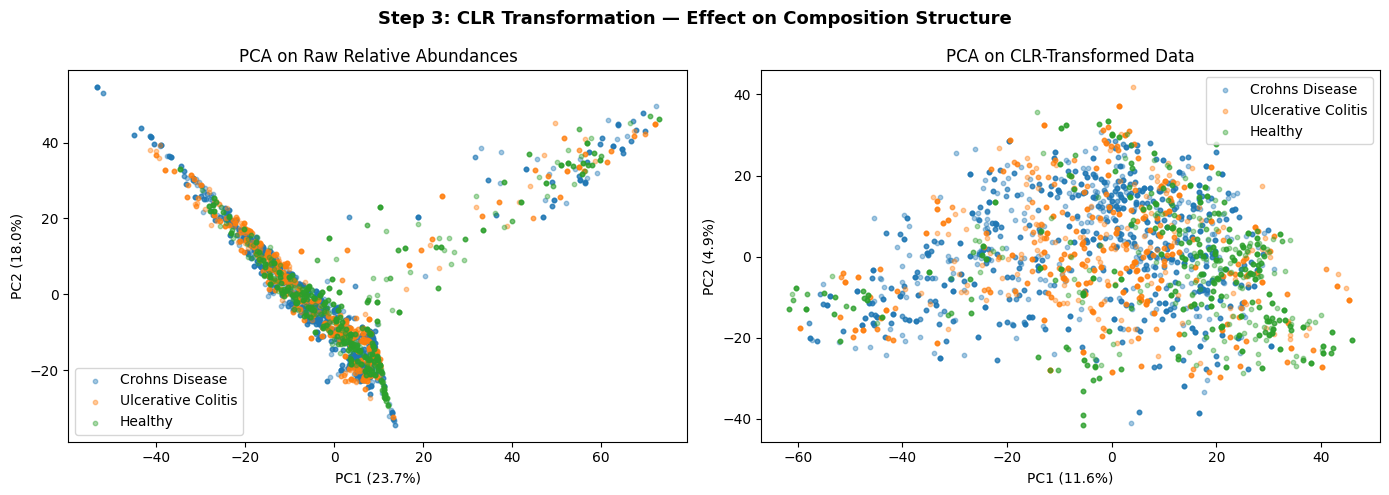

CLR matrix shape: (3387, 566)
CLR row sums, first 5 rows: [ 1.e-10 -0.e+00 -1.e-10 -0.e+00 -1.e-10]
Any NaNs in CLR matrix? False


In [4]:
# ── Step 3: CLR Transformation ─────────────────────────────────────────────
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 3a. Use relative abundance values directly ─────────────────────────────
# Your dataset already contains bacterial relative abundances, not raw counts.
X_rel = otu_df[otu_cols].astype(float).fillna(0).values

# Check for rows that sum to zero
row_sums = X_rel.sum(axis=1)
zero_sum_rows = row_sums == 0

print(f"Rows with total abundance = 0: {zero_sum_rows.sum()}")

# If any rows sum to zero, drop them from this analysis
if zero_sum_rows.sum() > 0:
    keep_mask = ~zero_sum_rows
    X_rel = X_rel[keep_mask]
    otu_df_clr_source = otu_df.loc[keep_mask].reset_index(drop=True)
else:
    otu_df_clr_source = otu_df.reset_index(drop=True)

# ── 3b. Add small pseudo-count to handle zeros ─────────────────────────────
PSEUDO = 1e-6
X_pseudo = X_rel + PSEUDO

# Re-normalize so each sample still sums to 1
X_pseudo = X_pseudo / X_pseudo.sum(axis=1, keepdims=True)

# ── 3c. CLR transformation ────────────────────────────────────────────────
def clr_transform(X):
    """Centered log-ratio transform. X should be positive and compositional."""
    log_X = np.log(X)
    log_geo_mean = log_X.mean(axis=1, keepdims=True)
    return log_X - log_geo_mean

clr_matrix = clr_transform(X_pseudo)

# Replace any remaining NaN or infinity values
clr_matrix = np.nan_to_num(clr_matrix, nan=0.0, posinf=0.0, neginf=0.0)

# Create CLR dataframe
clr_df = pd.DataFrame(clr_matrix, columns=[c + "_clr" for c in otu_cols])
clr_df["SubjectID"] = otu_df_clr_source["SubjectID"].values
clr_df["Disease"] = otu_df_clr_source["Disease"].values
clr_df["FlareLabel"] = otu_df_clr_source["FlareLabel"].values
clr_df["VisitNum"] = otu_df_clr_source["VisitNum"].values

# ── 3d. PCA comparison: raw relative abundance vs CLR ─────────────────────
pca_raw = PCA(n_components=2, random_state=SEED)
coords_raw = pca_raw.fit_transform(X_rel)

pca_clr = PCA(n_components=2, random_state=SEED)
coords_clr = pca_clr.fit_transform(clr_matrix)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for disease in otu_df_clr_source["Disease"].dropna().unique():
    mask = np.array(otu_df_clr_source["Disease"] == disease)

    axes[0].scatter(
        coords_raw[mask, 0],
        coords_raw[mask, 1],
        label=disease,
        alpha=0.4,
        s=10
    )

    axes[1].scatter(
        coords_clr[mask, 0],
        coords_clr[mask, 1],
        label=disease,
        alpha=0.4,
        s=10
    )

axes[0].set_title("PCA on Raw Relative Abundances")
axes[0].set_xlabel(f"PC1 ({pca_raw.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca_raw.explained_variance_ratio_[1]:.1%})")
axes[0].legend()

axes[1].set_title("PCA on CLR-Transformed Data")
axes[1].set_xlabel(f"PC1 ({pca_clr.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca_clr.explained_variance_ratio_[1]:.1%})")
axes[1].legend()

plt.suptitle(
    "Step 3: CLR Transformation — Effect on Composition Structure",
    fontsize=13,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"CLR matrix shape: {clr_matrix.shape}")
print(f"CLR row sums, first 5 rows: {clr_matrix.sum(axis=1)[:5].round(10)}")
print(f"Any NaNs in CLR matrix? {np.isnan(clr_matrix).any()}")

---

## Step 4 — Feature Engineering: Temporal Stability & Trajectory Features

| | **Project 15: Microbiome** |
|---|---|
| **Raw Features** | Raw Features | CLR-transformed bacterial relative abundance vector per sample (~500 taxa) |
| **Temporal Stability** | Bray-Curtis dissimilarity between consecutive samples per subject |
| **Trajectory Features** | Trajectory Features | Trailing mean and SD of CLR values over the previous 1–2 samples |
| **Stability Index** | Per-subject mean Bray-Curtis dissimilarity = microbiome instability score |
| **Delta Features** | Change in CLR value between current and previous sample per OTU |
| **Window Logic** | Uses the previous 1–2 visits as a trailing trajectory because sampling is irregular |
| **New Concept** | Bray-Curtis dissimilarity as a measure of compositional change (not Euclidean distance) |
| **Core Pitfall** | Rolling windows crossing subject boundaries; using the wrong data representation for each metric |

**What changes pedagogically:** Feature engineering focuses on capturing how the microbiome changes over time rather than its absolute state. Because samples are sparse and irregularly spaced, the key signal comes from *between-sample dissimilarity*. Bray-Curtis dissimilarity provides a way to quantify how much the microbiome shifts between visits, making it a central feature for modeling temporal instability.

**Challenge questions:**
- 74. Microbiome samples from the same person are temporally correlated. How do you account for within-subject correlation in your modeling? Samples from the same subject are correlated over time, so splitting at the sample level would leak information. This is addressed by performing subject-level splits and, ideally, leave-one-subject-out validation to ensure independence between training and testing data.
- 75. Antibiotic use causes dramatic rapid shifts in microbiome composition. Should you treat antibiotic courses as a covariate, an exclusion criterion, or a period of interest in its own right? Antibiotic use causes large perturbations in microbiome composition. It can be treated as a covariate to capture its effect, excluded to reduce noise, or studied as a separate condition of interest. In this project, it is best treated as a covariate because it provides meaningful explanatory context for sudden microbiome shifts.

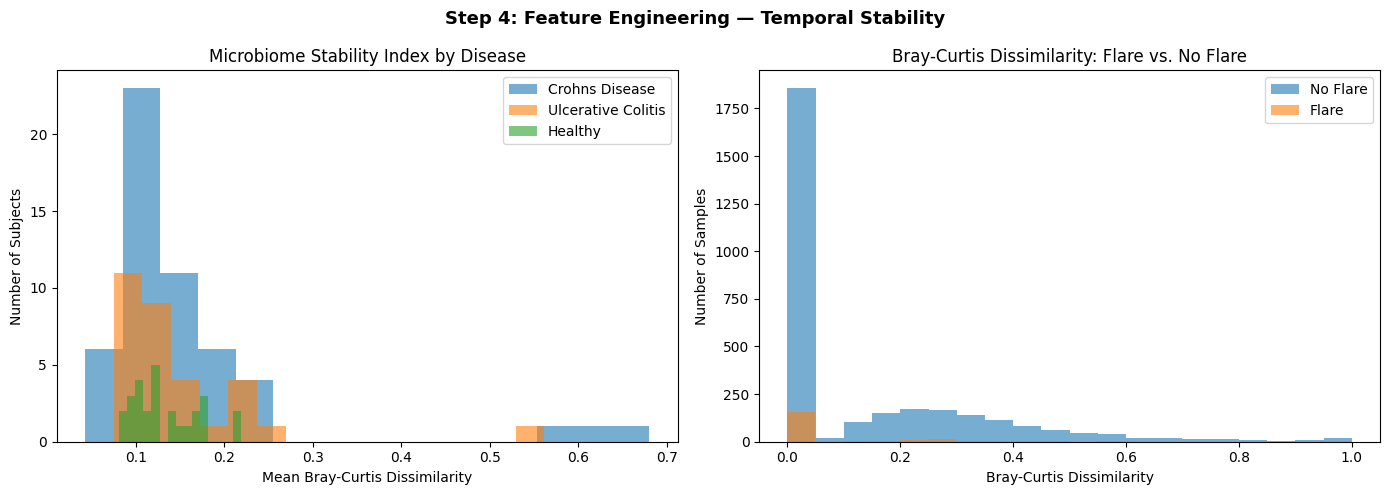

Feature matrix shape: (10553, 1699)
Flare prevalence in feature matrix: 8.3%
Number of engineered features: 1699


,SubjectID,VisitNum,Disease,FlareLabel,mean_Bacteroides vulgatus_clr,mean_Bacteroides uniformis_clr,mean_Bacteroides thetaiotaomicron_clr,mean_Faecalibacterium prausnitzii_clr,mean_Roseburia faecis_clr,mean_Bacteroides caccae_clr,...,delta_Prevotella pallens_clr,delta_Chlamydia ibidis_clr,delta_Enterococcus mundtii_clr,delta_Anaerostipes sp 992a_clr,delta_Actinobaculum sp oral taxon 183_clr,delta_Lachnoclostridium sp An298_clr,delta_Haemophilus haemolyticus_clr,delta_Enterococcus dispar_clr,delta_Atopobium minutum_clr,BrayCurtis
0,C3001,0.0,Crohns Disease,0,16.859394,16.557075,15.032159,14.779735,14.72617,14.131668,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000
1,C3001,0.0,Crohns Disease,0,16.859394,16.557075,15.032159,14.779735,14.72617,14.131668,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000
2,C3001,0.0,Crohns Disease,0,16.859394,16.557075,15.032159,14.779735,14.72617,14.131668,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000
3,C3001,0.0,Crohns Disease,0,16.859394,16.557075,15.032159,14.779735,14.72617,14.131668,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000
4,C3001,2.0,Crohns Disease,0,16.859394,16.557075,15.032159,14.779735,14.72617,14.131668,...,-0.27317,-0.27317,-0.27317,-0.27317,-0.27317,-0.27317,-0.27317,-0.27317,-0.27317,0.149517


In [5]:
# ── Step 4: Feature Engineering ────────────────────────────────────────────
from scipy.spatial.distance import braycurtis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CLR feature columns
clr_cols = [c for c in clr_df.columns if c.endswith("_clr")]

# Recreate aligned relative-abundance matrix for Bray-Curtis
# Bray-Curtis should be computed on relative abundances, not CLR values.
X_rel_bc = otu_df_clr_source[otu_cols].astype(float).fillna(0).values

# Normalize rows just in case they are not perfectly summed to 1
row_sums = X_rel_bc.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
X_rel_bc = X_rel_bc / row_sums

rel_df = pd.DataFrame(X_rel_bc, columns=otu_cols)
rel_df["SubjectID"] = otu_df_clr_source["SubjectID"].values
rel_df["Disease"] = otu_df_clr_source["Disease"].values
rel_df["FlareLabel"] = otu_df_clr_source["FlareLabel"].values
rel_df["VisitNum"] = otu_df_clr_source["VisitNum"].values

# ── 4a. Bray-Curtis dissimilarity between consecutive samples per subject ──
bc_records = []

for sid in clr_df["SubjectID"].unique():
    subj_meta = clr_df[clr_df["SubjectID"] == sid].sort_values("VisitNum").reset_index(drop=True)
    subj_rel = rel_df[rel_df["SubjectID"] == sid].sort_values("VisitNum").reset_index(drop=True)

    for i in range(1, len(subj_meta)):
        bc = braycurtis(
            subj_rel.loc[i - 1, otu_cols].values,
            subj_rel.loc[i, otu_cols].values
        )

        bc_records.append({
            "SubjectID": sid,
            "VisitNum": subj_meta.loc[i, "VisitNum"],
            "Disease": subj_meta.loc[i, "Disease"],
            "FlareLabel": subj_meta.loc[i, "FlareLabel"],
            "BrayCurtis": bc
        })

bc_df = pd.DataFrame(bc_records)

# ── 4b. Per-subject stability index ───────────────────────────────────────
stability_idx = (
    bc_df
    .groupby(["SubjectID", "Disease"])["BrayCurtis"]
    .mean()
    .reset_index()
    .rename(columns={"BrayCurtis": "StabilityIndex"})
)

# ── 4c. Trailing CLR trajectory features ──────────────────────────────────
feature_records = []

for sid in clr_df["SubjectID"].unique():
    subj = clr_df[clr_df["SubjectID"] == sid].sort_values("VisitNum").reset_index(drop=True)

    for i in range(1, len(subj)):
        # Use up to 2 prior samples as the trailing trajectory window
        window = subj.iloc[max(0, i - 2):i][clr_cols].astype(float)

        mean_vals = window.mean(axis=0).values
        sd_vals = window.std(axis=0).fillna(0).values

        current_vals = subj.iloc[i][clr_cols].astype(float).values
        previous_vals = subj.iloc[i - 1][clr_cols].astype(float).values
        delta_vals = current_vals - previous_vals

        record = {
            "SubjectID": sid,
            "VisitNum": subj.loc[i, "VisitNum"],
            "Disease": subj.loc[i, "Disease"],
            "FlareLabel": subj.loc[i, "FlareLabel"],
        }

        record.update({f"mean_{c}": v for c, v in zip(clr_cols, mean_vals)})
        record.update({f"sd_{c}": v for c, v in zip(clr_cols, sd_vals)})
        record.update({f"delta_{c}": v for c, v in zip(clr_cols, delta_vals)})

        feature_records.append(record)

feat_df = pd.DataFrame(feature_records)

# Add Bray-Curtis as a model feature too
feat_df = feat_df.merge(
    bc_df[["SubjectID", "VisitNum", "BrayCurtis"]],
    on=["SubjectID", "VisitNum"],
    how="left"
)

feat_df["BrayCurtis"] = feat_df["BrayCurtis"].fillna(0)

# ── 4d. Visualize stability index by disease ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for disease in stability_idx["Disease"].dropna().unique():
    subset = stability_idx[stability_idx["Disease"] == disease]["StabilityIndex"]
    axes[0].hist(subset, alpha=0.6, label=disease, bins=15)

axes[0].set_title("Microbiome Stability Index by Disease")
axes[0].set_xlabel("Mean Bray-Curtis Dissimilarity")
axes[0].set_ylabel("Number of Subjects")
axes[0].legend()

flare_bc = bc_df[bc_df["FlareLabel"] == 1]["BrayCurtis"]
noflare_bc = bc_df[bc_df["FlareLabel"] == 0]["BrayCurtis"]

axes[1].hist(noflare_bc, alpha=0.6, label="No Flare", bins=20)
axes[1].hist(flare_bc, alpha=0.6, label="Flare", bins=20)

axes[1].set_title("Bray-Curtis Dissimilarity: Flare vs. No Flare")
axes[1].set_xlabel("Bray-Curtis Dissimilarity")
axes[1].set_ylabel("Number of Samples")
axes[1].legend()

plt.suptitle(
    "Step 4: Feature Engineering — Temporal Stability",
    fontsize=13,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

feat_cols = [
    c for c in feat_df.columns
    if c.startswith("mean_") or c.startswith("sd_") or c.startswith("delta_")
]

feat_cols = feat_cols + ["BrayCurtis"]

print(f"Feature matrix shape: {feat_df[feat_cols].shape}")
print(f"Flare prevalence in feature matrix: {feat_df['FlareLabel'].mean():.1%}")
print(f"Number of engineered features: {len(feat_cols)}")

feat_df.head()

---

## Step 5 — Train / Test Split (Subject-Level)

| | **Project 15: Microbiome** |
|---|---|
| **Split Unit** | Subject (never by sample or visit) |
| **Split Ratio** | 80/20 subject-level split, stratified by disease group |
| **Stratification** | By disease group — preserve three-class balance in train and test |
| **Leakage Risk** | Sample-level split: a subject's samples appear in both train and test — inflates AUROC dramatically |
| **Cross-validation** | Leave-One-Subject-Out (LOSO-CV) is discussed as an appropriate extension |
| **New Evaluation Design** | Per-subject AUROC for flare prediction; microbiome dynamics vary greatly between people |
| **Core Pitfall** | Row-level or visit-level splits — classic clinical ML error |

**What changes pedagogically:** Splitting must be performed at the subject level because each individual contributes multiple correlated samples over time. This introduces an additional challenge: the dataset contains multiple disease groups (Healthy, Crohn’s disease, ulcerative colitis), so the split must preserve balance across these groups rather than a simple binary outcome.

In [6]:
# ── Step 5: Train / Test Split ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# ── 5a. Subject-level metadata ─────────────────────────────────────────────
subj_meta = (
    feat_df.groupby("SubjectID")["Disease"]
    .first()
    .reset_index()
)

subject_ids_arr = subj_meta["SubjectID"].values
disease_arr = subj_meta["Disease"].values

# ── 5b. Stratified subject-level 80/20 split ───────────────────────────────
train_subj, test_subj = train_test_split(
    subject_ids_arr,
    test_size=0.20,
    stratify=disease_arr,
    random_state=SEED
)

train_df = feat_df[feat_df["SubjectID"].isin(train_subj)].copy()
test_df = feat_df[feat_df["SubjectID"].isin(test_subj)].copy()

print(f"Train samples: {len(train_df)} | Test samples: {len(test_df)}")
print(f"Train subjects: {train_df['SubjectID'].nunique()} | Test subjects: {test_df['SubjectID'].nunique()}")

print("\nTrain disease distribution:")
print(train_df.groupby("Disease")["SubjectID"].nunique())

print("\nTest disease distribution:")
print(test_df.groupby("Disease")["SubjectID"].nunique())

print(f"\nTrain flare rate: {train_df['FlareLabel'].mean():.1%}")
print(f"Test flare rate:  {test_df['FlareLabel'].mean():.1%}")

# ── 5c. Prepare feature matrices ──────────────────────────────────────────
# Replace any remaining missing / infinite values before scaling
train_features = train_df[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
test_features = test_df[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

y_train = train_df["FlareLabel"].values
y_test = test_df["FlareLabel"].values

groups_train = train_df["SubjectID"].values
groups_test = test_df["SubjectID"].values

# ── 5d. Scale features using training set only ─────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(train_features)
X_test = scaler.transform(test_features)

print("\nSubject-level split complete.")
print("Scaler was fit on training data only.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Train samples: 8421 | Test samples: 2132
Train subjects: 88 | Test subjects: 23

Train disease distribution:
Disease
Crohns Disease        42
Healthy               21
Ulcerative Colitis    25
Name: SubjectID, dtype: int64

Test disease distribution:
Disease
Crohns Disease        11
Healthy                6
Ulcerative Colitis     6
Name: SubjectID, dtype: int64

Train flare rate: 8.1%
Test flare rate:  9.2%

Subject-level split complete.
Scaler was fit on training data only.
X_train shape: (8421, 1699)
X_test shape: (2132, 1699)


---

## Step 6 — Baseline Model: Logistic Regression

| | **Project 15: Microbiome** |
|---|---|
| **Input Features** | Trailing mean, SD, delta CLR features for each bacterial taxon, plus Bray-Curtis dissimilarity |
| **Model** | Logistic regression with `class_weight='balanced'`, L1 regularization (Lasso) |
| **Positive Rate** | ~15–25% of samples (within IBD subjects); lower if healthy subjects included |
| **Class Imbalance** | `class_weight='balanced'`; consider restricting to IBD subjects only |
| **Primary Metric** | AUROC + AUPRC — AUPRC is more informative under imbalance |
| **Clinical Baseline** | Stability index alone: predict active inflammation if Bray-Curtis exceeds a threshold |
| **Interpretability** | Coefficients on CLR OTU features — which taxa are most predictive? |
| **Core Pitfall** | Reporting accuracy — trivially high by always predicting no-flare |

**What changes pedagogically:** With hundreds to thousands of engineered microbiome features and a limited number of subjects..., regularization is essential. L1 (Lasso) naturally produces sparse models — interpretable as “which bacterial taxa or trajectory features matter”

Model                                  AUROC    AUPRC
-------------------------------------------------------
Clinical Rule: Bray-Curtis             0.478    0.118
Logistic Regression (L1)               0.633    0.274

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1935
           1       0.32      0.17      0.22       197

    accuracy                           0.89      2132
   macro avg       0.62      0.57      0.58      2132
weighted avg       0.86      0.89      0.87      2132


Clinical Rule Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1935
           1       0.09      0.23      0.13       197

    accuracy                           0.71      2132
   macro avg       0.50      0.50      0.48      2132
weighted avg       0.83      0.71      0.76      2132



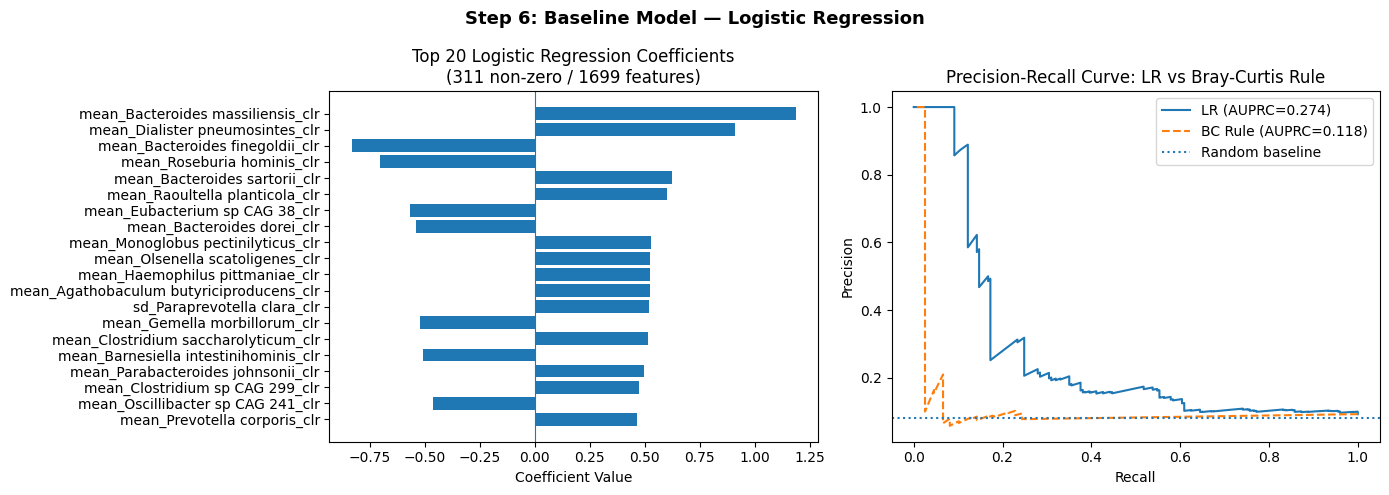


Non-zero features retained by L1 model: 311 / 1699


In [7]:
# ── Step 6: Baseline Logistic Regression ───────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    classification_report
)
import numpy as np
import matplotlib.pyplot as plt

# ── 6a. Logistic regression with L1 regularization ────────────────────────
lr = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    class_weight="balanced",
    random_state=SEED,
    max_iter=1000
)

lr.fit(X_train, y_train)

y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

auroc_lr = roc_auc_score(y_test, y_prob_lr)
auprc_lr = average_precision_score(y_test, y_prob_lr)

# ── 6b. Clinical baseline: Bray-Curtis threshold rule ─────────────────────
# Higher Bray-Curtis = larger microbiome change from previous sample
bc_feature = test_df["BrayCurtis"].replace([np.inf, -np.inf], np.nan).fillna(0).values

bc_threshold = np.percentile(train_df["BrayCurtis"].fillna(0), 75)
y_rule = (bc_feature > bc_threshold).astype(int)

auroc_rule = roc_auc_score(y_test, bc_feature)
auprc_rule = average_precision_score(y_test, bc_feature)

print("=" * 55)
print(f"{'Model':<35} {'AUROC':>8} {'AUPRC':>8}")
print("-" * 55)
print(f"{'Clinical Rule: Bray-Curtis':<35} {auroc_rule:>8.3f} {auprc_rule:>8.3f}")
print(f"{'Logistic Regression (L1)':<35} {auroc_lr:>8.3f} {auprc_lr:>8.3f}")
print("=" * 55)

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

print("\nClinical Rule Classification Report:")
print(classification_report(y_test, y_rule, zero_division=0))

# ── 6c. Feature importance: top features by absolute coefficient ──────────
coef = lr.coef_[0]
n_nonzero = (coef != 0).sum()

top_idx = np.argsort(np.abs(coef))[::-1][:20]
top_features = [feat_cols[i] for i in top_idx]
top_coefs = coef[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    top_features[::-1],
    top_coefs[::-1]
)
axes[0].set_title(
    f"Top 20 Logistic Regression Coefficients\n"
    f"({n_nonzero} non-zero / {len(feat_cols)} features)"
)
axes[0].set_xlabel("Coefficient Value")
axes[0].axvline(0, linewidth=0.8)

# Precision-recall curve comparison
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rule, rec_rule, _ = precision_recall_curve(y_test, bc_feature)

axes[1].plot(rec_lr, prec_lr, label=f"LR (AUPRC={auprc_lr:.3f})")
axes[1].plot(rec_rule, prec_rule, linestyle="--", label=f"BC Rule (AUPRC={auprc_rule:.3f})")
axes[1].axhline(y_train.mean(), linestyle=":", label="Random baseline")

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve: LR vs Bray-Curtis Rule")
axes[1].legend()

plt.suptitle(
    "Step 6: Baseline Model — Logistic Regression",
    fontsize=13,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"\nNon-zero features retained by L1 model: {n_nonzero} / {len(feat_cols)}")

---

## Step 7 — Temporal Model: LSTM on Microbiome Trajectories

| | **Project 15: Microbiome** |
|---|---|
| **Input Sequence** | Fixed-length trailing sequence of engineered microbiome features from previous visits |
| **Sequence Length** | SEQ_LEN = 4 prior visits; because sampling is irregular, this is not exactly four equal time intervals |
| **Architecture** | 1-layer LSTM, 64 hidden units, dropout 0.3, sigmoid output |
| **Loss Function** | Weighted BCE (class_weight proportional to imbalance) |
| **Key Advantage Over LR** | Learns temporal patterns across several previous visits, while LR uses engineered summary features |
| **New Consideration** | Very sparse temporal coverage — LSTM input sequences contain only a few observations (e.g., 2–4 visits), limiting the amount of temporal information available |
| **Prediction Horizon** | 1 sample (≈ 2 weeks) before clinical flare |
| **Core Pitfall** | Exploding gradients; padding sequences naively without masking |

**What changes pedagogically:** The LSTM must handle *very short, irregular* sequences, often containing only a few observations in the trailing window. This limits the temporal information available to the model and raises an important question: does a complex temporal model provide meaningful gains over simpler approaches when the sequence length is so short?

**Challenge questions:**
- 76. IBD flares are defined clinically. If the microbiome changes precede the clinical flare, does your model capture a causal signal or a correlational one? How would you distinguish these? The model captures a correlational signal rather than a causal one. While microbiome changes may precede a clinical flare, this temporal ordering does not imply that the microbiome is causing the flare. To distinguish causality, one would need controlled interventions (e.g., altering the microbiome and observing outcomes) or longitudinal designs that isolate microbiome changes independently of disease progression.

Train sequences: (8079, 4, 1699)
Test sequences: (2040, 4, 1699)
Model                                  AUROC    AUPRC
-------------------------------------------------------
Clinical Rule: Bray-Curtis             0.478    0.118
Logistic Regression (L1)               0.633    0.274
LSTM (seq_len=4)                       0.637    0.244


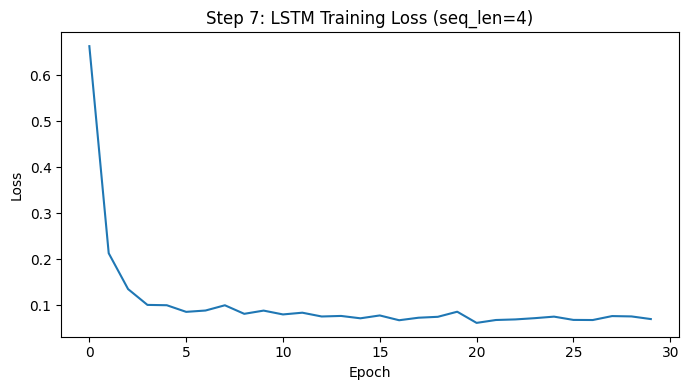

In [8]:
# ── Step 7: LSTM on Microbiome Trajectories ────────────────────────────────

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

SEQ_LEN = 4
N_FEATURES = len(feat_cols)
HIDDEN = 64
DROPOUT = 0.3
EPOCHS = 30
LR = 1e-3

# ── 7a. Build fixed-length sequences per subject ───────────────────────────
def build_sequences(df, feat_cols, seq_len):
    X_seq, y_seq, groups = [], [], []

    for sid in df["SubjectID"].unique():
        subj = df[df["SubjectID"] == sid].sort_values("VisitNum").reset_index(drop=True)

        vals = (
            subj[feat_cols]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
            .values
        )

        labels = subj["FlareLabel"].values

        for i in range(seq_len, len(subj)):
            X_seq.append(vals[i-seq_len:i])
            y_seq.append(labels[i])
            groups.append(sid)

    return np.array(X_seq), np.array(y_seq), np.array(groups)

X_tr_seq, y_tr_seq, g_tr = build_sequences(train_df, feat_cols, SEQ_LEN)
X_te_seq, y_te_seq, g_te = build_sequences(test_df, feat_cols, SEQ_LEN)

print(f"Train sequences: {X_tr_seq.shape}")
print(f"Test sequences: {X_te_seq.shape}")

if len(X_tr_seq) == 0 or len(X_te_seq) == 0:
    raise ValueError("Not enough samples per subject to build LSTM sequences. Try SEQ_LEN = 2.")

# ── 7b. Scale sequence features using the Step 5 scaler ────────────────────
X_tr_seq_scaled = scaler.transform(
    X_tr_seq.reshape(-1, N_FEATURES)
).reshape(-1, SEQ_LEN, N_FEATURES)

X_te_seq_scaled = scaler.transform(
    X_te_seq.reshape(-1, N_FEATURES)
).reshape(-1, SEQ_LEN, N_FEATURES)

Xt = torch.FloatTensor(X_tr_seq_scaled)
yt = torch.FloatTensor(y_tr_seq)
Xv = torch.FloatTensor(X_te_seq_scaled)
yv = torch.FloatTensor(y_te_seq)

# Positive class weight for imbalance
pos_rate = y_tr_seq.mean()
pos_weight_value = (1 - pos_rate) / pos_rate if pos_rate > 0 else 1.0
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(Xt, yt),
    batch_size=32,
    shuffle=True
)

# ── 7c. LSTM model ────────────────────────────────────────────────────────
class MicrobiomeLSTM(nn.Module):
    def __init__(self, n_feat, hidden, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_feat,
            hidden_size=hidden,
            batch_first=True
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        logits = self.fc(self.drop(h[-1])).squeeze(1)
        return logits

model = MicrobiomeLSTM(N_FEATURES, HIDDEN, DROPOUT)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── 7d. Training loop ─────────────────────────────────────────────────────
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

# ── 7e. Evaluation ────────────────────────────────────────────────────────
model.eval()

with torch.no_grad():
    logits = model(Xv)
    y_prob_lstm = torch.sigmoid(logits).numpy()

auroc_lstm = roc_auc_score(y_te_seq, y_prob_lstm)
auprc_lstm = average_precision_score(y_te_seq, y_prob_lstm)

print("=" * 55)
print(f"{'Model':<35} {'AUROC':>8} {'AUPRC':>8}")
print("-" * 55)
print(f"{'Clinical Rule: Bray-Curtis':<35} {auroc_rule:>8.3f} {auprc_rule:>8.3f}")
print(f"{'Logistic Regression (L1)':<35} {auroc_lr:>8.3f} {auprc_lr:>8.3f}")
print(f"{'LSTM (seq_len=' + str(SEQ_LEN) + ')':<35} {auroc_lstm:>8.3f} {auprc_lstm:>8.3f}")
print("=" * 55)

plt.figure(figsize=(7, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Step 7: LSTM Training Loss (seq_len={SEQ_LEN})")
plt.tight_layout()
plt.show()

---

## Step 8 — Evaluation: Beyond AUROC

| | **Project 15: Microbiome** |
|---|---|
| **Primary Metric** | UROC + AUPRC; per-subject AUROC to assess heterogeneity across individuals |
| **Timing** | Lead time: how many visits before the clinical flare the model prediction increases |
| **False Alarm Cost** | Moderate — unnecessary clinical intervention; patient anxiety |
| **New Evaluation Challenge** | Microbiome changes may precede the *diagnosis* of a flare, not the *onset* — labeling lag |
| **Subgroup Analysis** | Per-disease-group AUROC (Healthy vs. CD vs. UC); per-subject AUROC |
| **Calibration** | Platt scaling; calibration curve — important given rare-event rate |
| **Core Pitfall** | Optimizing population-level AUROC while performance is heterogeneous across subjects |

**What changes pedagogically:** Unlike the CGM prevented-event paradox (an acted-on alarm becomes a false positive), here the challenge is *label timing*. If the microbiome shifts 2 weeks before the patient reports to the clinic with a flare, the clinical label date understates the model's true lead time. Evaluation must account for this lag.

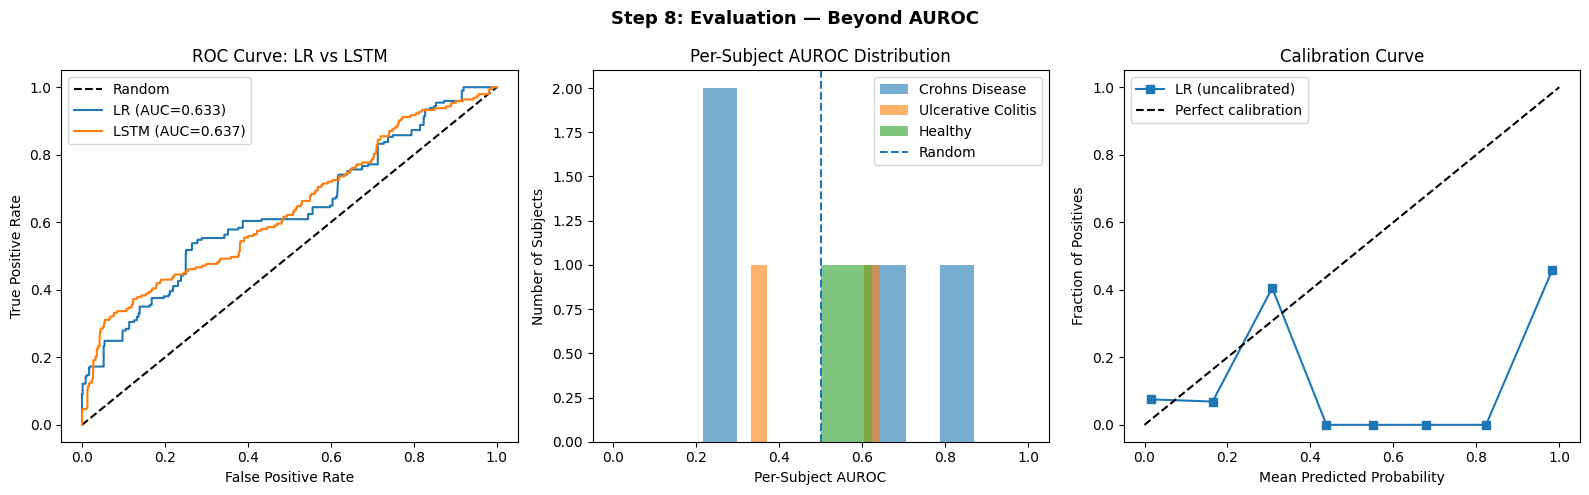


Per-subject AUROC by disease group:
                    count   mean    std    min   25%    50%    75%    max
Disease                                                                  
Crohns Disease        4.0  0.495  0.317  0.217  0.24  0.447  0.702  0.869
Healthy               1.0  0.500    NaN  0.500  0.50  0.500  0.500  0.500
Ulcerative Colitis    2.0  0.488  0.219  0.333  0.41  0.488  0.566  0.643


In [9]:
# ── Step 8: Evaluation ─────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── 8a. Per-subject AUROC (LR model) ─────────────────────────────────────
test_df_eval = test_df.copy().reset_index(drop=True)

# attach predictions safely
test_df_eval["y_prob_lr"] = y_prob_lr

per_subj_auroc = []

for sid in test_df_eval["SubjectID"].unique():
    subj = test_df_eval[test_df_eval["SubjectID"] == sid]

    # must have both classes present
    if subj["FlareLabel"].nunique() < 2:
        continue

    auroc_s = roc_auc_score(subj["FlareLabel"], subj["y_prob_lr"])
    disease_s = subj["Disease"].iloc[0]

    per_subj_auroc.append({
        "SubjectID": sid,
        "Disease": disease_s,
        "AUROC": auroc_s
    })

per_subj_df = pd.DataFrame(per_subj_auroc)

# ── 8b. Visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC comparison (only if both models valid)
axes[0].plot([0, 1], [0, 1], "k--", label="Random")

if len(np.unique(y_test)) > 1:
    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
    axes[0].plot(fpr_lr, tpr_lr, label=f"LR (AUC={auroc_lr:.3f})")

if len(np.unique(y_te_seq)) > 1:
    fpr_lstm, tpr_lstm, _ = roc_curve(y_te_seq, y_prob_lstm)
    axes[0].plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={auroc_lstm:.3f})")

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve: LR vs LSTM")
axes[0].legend()

# ── Per-subject AUROC distribution ────────────────────────────────────────
if len(per_subj_df) > 0:
    for disease in per_subj_df["Disease"].unique():
        subset = per_subj_df[per_subj_df["Disease"] == disease]["AUROC"]
        axes[1].hist(subset, alpha=0.6, label=disease, bins=8)

    axes[1].axvline(0.5, linestyle="--", label="Random")
    axes[1].set_xlabel("Per-Subject AUROC")
    axes[1].set_ylabel("Number of Subjects")
    axes[1].set_title("Per-Subject AUROC Distribution")
    axes[1].legend()
else:
    axes[1].set_title("No valid per-subject AUROC (insufficient variation)")

# ── Calibration curve ─────────────────────────────────────────────────────
if len(np.unique(y_test)) > 1:
    frac_pos, mean_pred = calibration_curve(y_test, y_prob_lr, n_bins=8)

    axes[2].plot(mean_pred, frac_pos, "s-", label="LR (uncalibrated)")
    axes[2].plot([0, 1], [0, 1], "k--", label="Perfect calibration")

    axes[2].set_xlabel("Mean Predicted Probability")
    axes[2].set_ylabel("Fraction of Positives")
    axes[2].set_title("Calibration Curve")
    axes[2].legend()
else:
    axes[2].set_title("Calibration not available (single class)")

plt.suptitle(
    "Step 8: Evaluation — Beyond AUROC",
    fontsize=13,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# ── 8c. Summary statistics ────────────────────────────────────────────────
if len(per_subj_df) > 0:
    print("\nPer-subject AUROC by disease group:")
    print(per_subj_df.groupby("Disease")["AUROC"].describe().round(3))
else:
    print("\nNo valid per-subject AUROC computed (subjects lack both classes).")

---

## Step 9 — Model Interpretation with SHAP & PCoA Trajectory Visualization

| | **Project 15: Microbiome** |
|---|---|
| **Explainer** | `shap.LinearExplainer` for LR; `shap.DeepExplainer` for LSTM |
| **Summary Plot** | SHAP feature importance: which bacterial taxa or trajectory features drive active inflammation predictions |
| **Local Explanation** | Waterfall plot: why did this subject's sample trigger a flare prediction? |
| **New Visualization** | PCoA trajectory per subject colored by disease status and flare events |
| **Biological Grounding** | High-SHAP bacterial taxa should be interpreted carefully and compared with known IBD-associated taxa |
| **Clinician Communication** | "Your microbiome shifted away from its healthy baseline state" + show PCoA trajectory |
| **Core Pitfall** | High SHAP value ≠ causation; confusing global feature importance with local per-subject explanation |

**What changes pedagogically:** The PCoA trajectory visualization is new — it shows *where* a subject moves in microbiome space over time and whether that trajectory predicts a flare. This combines interpretability (SHAP) with a clinically intuitive visualization (the dysbiosis map).

**Challenge questions:**
- 76. If the microbiome changes precede the clinical flare, does your model capture a causal signal or a correlational one? How would you distinguish these using the SHAP outputs and the PCoA trajectory? SHAP values identify which features are associated with predictions, and PCoA trajectories visualize how the microbiome evolves over time, but both remain descriptive tools. They can show that certain taxa or trajectory patterns consistently precede flare predictions, suggesting a predictive relationship. However, they cannot establish causality, because they do not account for confounding factors or intervention effects. Demonstrating causality would require experimental or quasi-experimental designs beyond observational modeling.

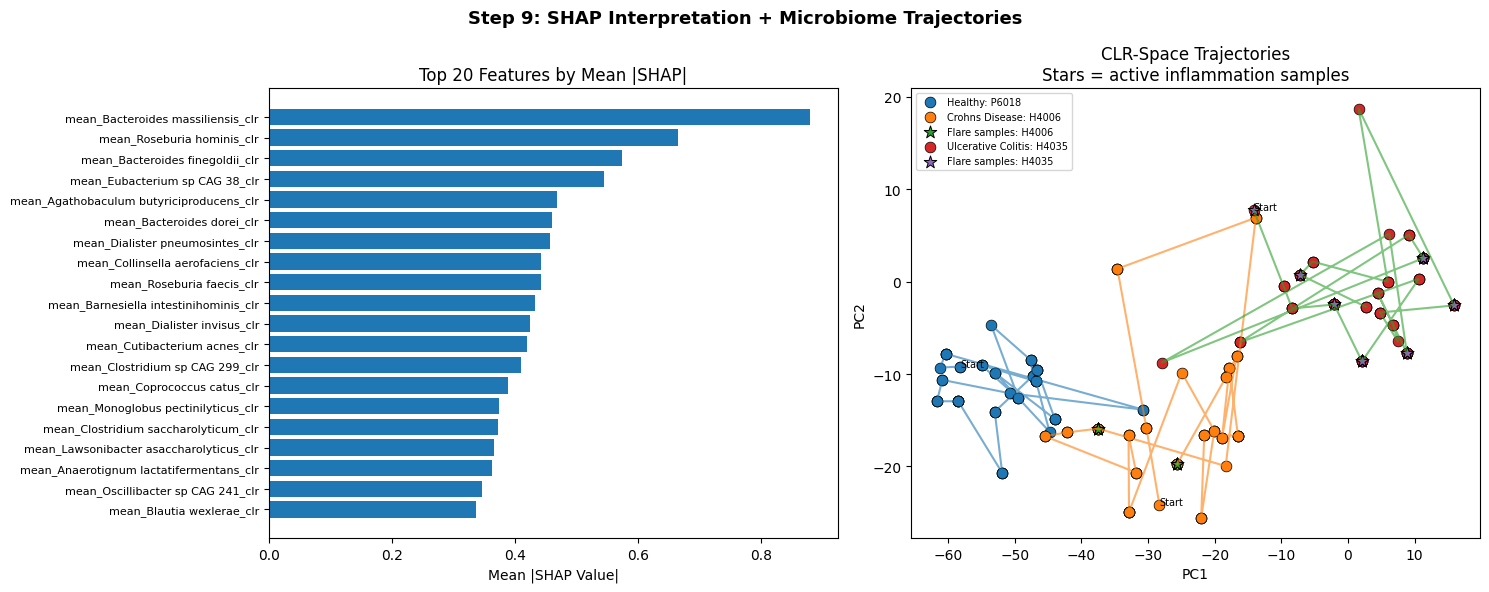

Top 20 SHAP-ranked features:
mean_Bacteroides massiliensis_clr: 0.8808
mean_Roseburia hominis_clr: 0.6657
mean_Bacteroides finegoldii_clr: 0.5738
mean_Eubacterium sp CAG 38_clr: 0.5455
mean_Agathobaculum butyriciproducens_clr: 0.4682
mean_Bacteroides dorei_clr: 0.4610
mean_Dialister pneumosintes_clr: 0.4575
mean_Collinsella aerofaciens_clr: 0.4433
mean_Roseburia faecis_clr: 0.4426
mean_Barnesiella intestinihominis_clr: 0.4337
mean_Dialister invisus_clr: 0.4256
mean_Cutibacterium acnes_clr: 0.4205
mean_Clostridium sp CAG 299_clr: 0.4111
mean_Coprococcus catus_clr: 0.3899
mean_Monoglobus pectinilyticus_clr: 0.3741
mean_Clostridium saccharolyticum_clr: 0.3724
mean_Lawsonibacter asaccharolyticus_clr: 0.3657
mean_Anaerotignum lactatifermentans_clr: 0.3639
mean_Oscillibacter sp CAG 241_clr: 0.3465
mean_Blautia wexlerae_clr: 0.3376


In [10]:
# ── Step 9: Interpretation — SHAP + PCoA Trajectories ─────────────────────

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 9a. SHAP on Logistic Regression ───────────────────────────────────────
explainer = shap.LinearExplainer(lr, X_train)
shap_values = explainer.shap_values(X_test)

mean_shap = np.abs(shap_values).mean(axis=0)
top20_idx = np.argsort(mean_shap)[::-1][:20]
top20_names = [feat_cols[i] for i in top20_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# SHAP summary bar plot
axes[0].barh(top20_names[::-1], mean_shap[top20_idx][::-1])
axes[0].set_title("Top 20 Features by Mean |SHAP|")
axes[0].set_xlabel("Mean |SHAP Value|")
axes[0].tick_params(axis="y", labelsize=8)

# ── 9b. PCoA/PCA trajectories for selected subjects ───────────────────────
# Uses CLR-space coordinates from Step 3
pca_coord_df = pd.DataFrame(coords_clr, columns=["PC1", "PC2"])
pca_coord_df["SubjectID"] = otu_df_clr_source["SubjectID"].values
pca_coord_df["Disease"] = otu_df_clr_source["Disease"].values
pca_coord_df["VisitNum"] = otu_df_clr_source["VisitNum"].values
pca_coord_df["FlareLabel"] = otu_df_clr_source["FlareLabel"].values

# Select one subject from each disease group if available
selected = []

for disease in ["Healthy", "Crohns Disease", "Ulcerative Colitis", "CD", "UC"]:
    candidates = (
        pca_coord_df[pca_coord_df["Disease"] == disease]
        .groupby("SubjectID")
        .size()
        .sort_values(ascending=False)
    )

    if len(candidates) > 0:
        selected.append((candidates.index[0], disease))

# Keep only first 3 selected subjects
selected = selected[:3]

for sid, disease in selected:
    subj_traj = (
        pca_coord_df[pca_coord_df["SubjectID"] == sid]
        .sort_values("VisitNum")
    )

    axes[1].plot(
        subj_traj["PC1"],
        subj_traj["PC2"],
        "-",
        alpha=0.6,
        linewidth=1.5
    )

    axes[1].scatter(
        subj_traj["PC1"],
        subj_traj["PC2"],
        s=60,
        edgecolors="black",
        linewidth=0.5,
        label=f"{disease}: {sid}"
    )

    flare_points = subj_traj[subj_traj["FlareLabel"] == 1]

    if len(flare_points) > 0:
        axes[1].scatter(
            flare_points["PC1"],
            flare_points["PC2"],
            s=90,
            marker="*",
            edgecolors="black",
            linewidth=0.7,
            label=f"Flare samples: {sid}"
        )

    if len(subj_traj) > 0:
        axes[1].annotate(
            "Start",
            (subj_traj["PC1"].iloc[0], subj_traj["PC2"].iloc[0]),
            fontsize=7
        )

axes[1].set_title("CLR-Space Trajectories\nStars = active inflammation samples")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=7)

plt.suptitle(
    "Step 9: SHAP Interpretation + Microbiome Trajectories",
    fontsize=13,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

print("Top 20 SHAP-ranked features:")
for name, value in zip(top20_names, mean_shap[top20_idx]):
    print(f"{name}: {value:.4f}")

*I 320D Spring 2026 · University of Texas at Austin · School of Information*  
*Joshua Hamilton, Student*